<a href="https://colab.research.google.com/github/ldaniel-hm/eml_approximate/blob/main/Dos_formas_de_discretizar_espacios_continuos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dos Formas de Discretizar Espacios Continuos**

En este notebook se muestra como adaptar los espacios de estados continuos para que se puedan aplicar los métodos tabulares de aprendizaje por refuerzo en el entorno Gymnasium


## Preparamos el entorno que se usará en el notebook


In [14]:
#@title Importamos las librerias necesarias
import random
import gymnasium as gym
from gymnasium import ObservationWrapper
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from environments.mountain_car import make_mountain_car_env
from utils.discretizar import StateAggregationEnv
from algorithms.sarsa import SARSAApprox
from utils.plotting import plot_curve
from policies.epsilon_greedy import compute_q

In [15]:
#@title Cargamos el entorno
NUM_EPISODES = 5000
SEED = 100
BIN_SIZE = 20

env = make_mountain_car_env(seed=SEED, render_mode="rgb_array")

print("Estados:", env.observation_space)
print("Acciones:", env.action_space)


Estados: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Acciones: Discrete(3)


In [16]:
def summarize_results(name, rewards):
    print(f"\n=== {name} ===")
    print(f"Máximo: {np.max(rewards):.2f}")
    print(f"Media últimos 100: {np.mean(rewards[-100:]):.2f}")
    print(f"Último episodio: {rewards[-1]:.2f}")

## Este es el entorno

In [17]:
env.render()

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

### **Las acciones del entorno**

La acciones disponibles son:
- 0: Acelerar a la izquierda.
- 1: No acelerar
- 2: Acelerar a la derecha

### **Los estados del entorno**

Las observaciones es un ndarray con dimensión (2,) donde los elementos se corresponde a los siguientes valores:

| Número | Observación                          | Mínimo | Máximo | Unidad        |
|--------|--------------------------------------|--------|--------|---------------|
| 0      | Posición del coche en el eje x      | -1.2   | 0.6    | posición (m)  |
| 1      | Velocidad del coche                 | -0.07  | 0.07   | velocidad (v) |


# Discretización usando Agregación

Podemos pasar de un espacio continuo de observaciones $[-1.2, 0.6]\times [-0.07, 0.07]$ a un espacio discreto. Para ello, discretizamos cada dimensión con una partición de intervalos. A esto se le llama **agregación.**


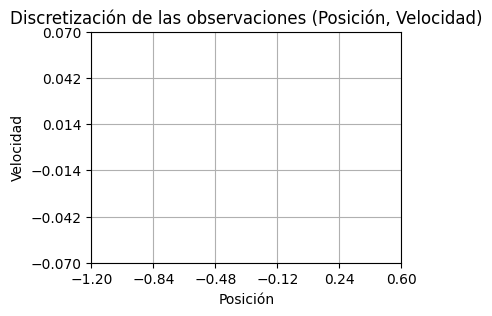

In [18]:
#@title Por ejemplo, podemos discretizar el espacio en solo 25 observaciones
# Definir los rangos para la posición y la velocidad
x_min, x_max = -1.2, 0.6    # Rango para la posición (eje X)
y_min, y_max = -0.07, 0.07  # Rango para la velocidad (eje Y)

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(4, 3))

# Establecer los límites de los ejes
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Dividir el eje X en 5 partes (6 ticks) y el eje Y en 5 partes (6 ticks)
x_ticks = np.linspace(x_min, x_max, 6)
y_ticks = np.linspace(y_min, y_max, 6)

# Asignar los ticks a los ejes
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

# Activar la grilla para mostrar las divisiones
ax.grid(True)

# Etiquetas y título para la gráfica
ax.set_xlabel("Posición")
ax.set_ylabel("Velocidad")
ax.set_title("Discretización de las observaciones (Posición, Velocidad)")

# Mostrar la gráfica
plt.show()

### Creamos *una* agregación de estados

- Necesitamos hacer un Wrapper sobre el espacio de observaciones
- Vamos a discritizar para trabajar con 400 estados. La posición se discretiza en 20 valores y la velocidad en otros 20 valores

In [19]:
#@title Dividimos cada dimensión en 20 intervalos. Al nuevo espacio lo llamaremos *saenv*

bins = np.array([BIN_SIZE, BIN_SIZE])
low = env.observation_space.low
high = env.observation_space.high
saenv = StateAggregationEnv(env, bins=bins, low=low, high=high)
saenv.buckets

[array([-1.2       , -1.1       , -1.        , -0.90000004, -0.8000001 ,
        -0.70000005, -0.6       , -0.50000006, -0.40000004, -0.3       ,
        -0.20000005, -0.10000002,  0.        ,  0.10000002,  0.19999993,
         0.29999995,  0.39999998,  0.5       ,  0.6       ], dtype=float32),
 array([-0.07      , -0.06222222, -0.05444444, -0.04666667, -0.03888889,
        -0.03111111, -0.02333333, -0.01555555, -0.00777778,  0.        ,
         0.00777778,  0.01555556,  0.02333333,  0.03111111,  0.03888889,
         0.04666667,  0.05444445,  0.06222222,  0.07      ], dtype=float32)]

In [20]:
#@title Comparamos el entorno original con el entorno con estados agregados

print(f"El espacio de observaciones original es: {env.observation_space}, \n\
Un estado para este espacio es: {env.observation_space.sample()}")
print(f"El espacio de estados modificado es: {saenv.observation_space}, \n\
Un estado para este espacio es: {saenv.observation_space.sample()}")

El espacio de observaciones original es: Box([-1.2  -0.07], [0.6  0.07], (2,), float32), 
Un estado para este espacio es: [-0.6790358  -0.04649187]
El espacio de estados modificado es: MultiDiscrete([20 20]), 
Un estado para este espacio es: [1 8]


## **Cómo usar los desarrollos sobre Agregación**

Ya podemos trabajar con los algoritmos tabulares como SARSA o Q-Learning.


Ahora, nuestra función $Q$ es $Q(s,a)=Q((s_1, s_2), a)$. Donde $a$ es una de las 3 posibles acciones que se puede tomar en el estado (pos, vel) y $(s_1, s_2)$ son las coordenadas en cada dimensión del espacio discretizado. Cada dimensión se ha dividido en 20 subintervalos. Queremos la siguiente tabla de valores Q

| Posición | Velocidad | Acción | Q(s, a) |
|--------|-----------|--------|----- |
| 1  | 1 | 0 | Q(1,1,0) |
| 1  | 1 | 1 | Q(1,1,1) |
| 1  | 1 | 2 | Q(1,1,2) |
|..| .. | |
| 20 | 20 | 2 | Q(20,20,2) |


La tabla de valores inicial, para este caso, sería:

```
action_values_Q = np.zeros((20,20, 3))
```



Para conocer el resultado de una acción:
```
next_state, reward, done, _, _ = saenv.step(action)
```

Este resultado lo podremos usar, por ejemplo, para SARSA como:

```
qsa = action_values_Q[state][action]
next_qsa = action_values_Q[next_state][next_action]
action_values_Q[state][action] = qsa + alpha * (reward + gamma * next_qsa - qsa)
```


En cuanto a cómo elegir la acción a tomar se puede usar el siguiente código

```
def policy(state, epsilon=0.1):
    if np.random.random() < epsilon:
        return np.random.randint(3)  # Hay 3 acciones posibles: 0, 1, 2.
    else:
        av = action_values[state]
        return np.random.choice(np.flatnonzero(av == av.max()))
```

Si `av=[3.0, 2.0, 3.0]`, el máximo es `3` con índices `[0,2]=np.flatnonzero(av == av.max())`. Entonces, `np.random.choice([0,2])` elige uno al azar.



In [21]:
#@title Aprendizaje SARSA semi-gradiente

state_dim = np.prod(saenv.observation_space.nvec)

sarsa_approx = SARSAApprox(
    saenv,
    feature_dim=state_dim,
    n_actions=saenv.action_space.n,
    alpha=0.5,
    discount_factor=1,
    epsilon=0.3
)

sarsa_rewards, sarsa_steps = sarsa_approx.train(NUM_EPISODES)

SARSA semi-gradiente: 100%|██████████| 5000/5000 [00:38<00:00, 129.32it/s]


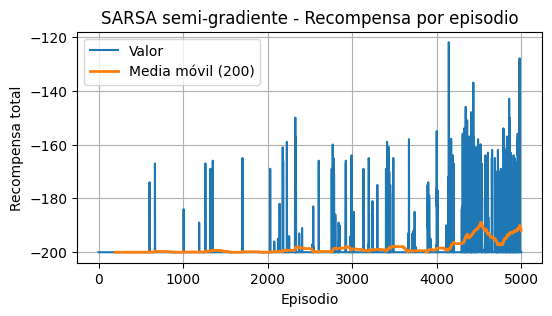

In [22]:
#@title Recompensa por episodio

plot_curve(
    sarsa_rewards,
    title="SARSA semi-gradiente - Recompensa por episodio",
    ylabel="Recompensa total",
    moving_avg_window=200
)

In [23]:
summarize_results("SARSA semi-gradiente", sarsa_rewards)


=== SARSA semi-gradiente ===
Máximo: -122.00
Media últimos 100: -190.90
Último episodio: -200.00


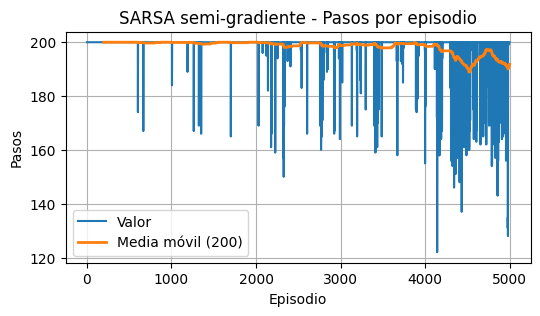

In [24]:
plot_curve(
    sarsa_steps,
    title="SARSA semi-gradiente - Pasos por episodio",
    ylabel="Pasos",
    moving_avg_window=200
)

In [25]:
#@title Inspección del modelo aprendido

print("Shape de theta:", sarsa_approx.theta.shape)
print("Norma de los pesos:", np.linalg.norm(sarsa_approx.theta))

Shape de theta: (3, 400)
Norma de los pesos: 2176.7859873799575


In [26]:
# #@title Política greedy obtenida

# state, _ = saenv.reset()
# done = False

# actions = []

# while not done:

#     action = np.argmax(compute_q(sarsa_approx, state))
#     actions.append(str(action))

#     state, _, terminated, truncated, _ = saenv.step(action)
#     done = terminated or truncated

# actions_str = ", ".join(actions)

# print("Secuencia de acciones greedy:", actions_str)